# Inheritance
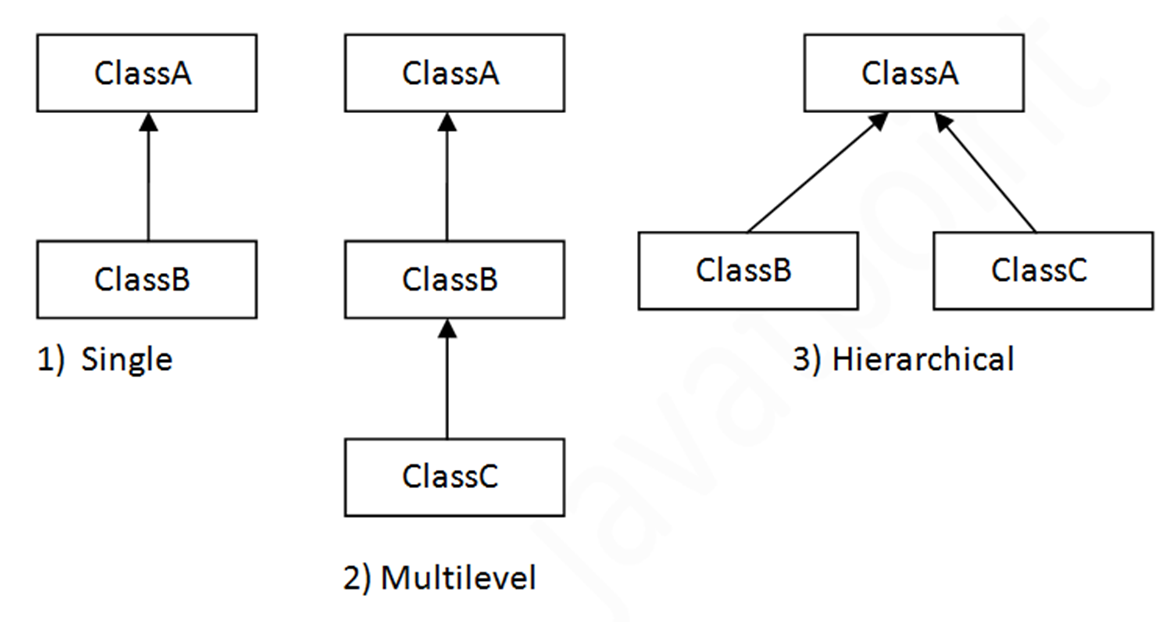


# 1. Single Inheritance
1. One Parent class one child class
2. Child class inherits attributes and methods of parent class

In [4]:
class Person:
    def __init__(self, name: str, age: int):
        self.name = name
        self.age = age

    def intro(self):
        print(f"My name is {self.name}")
        print(f"I am {self.age} years old")

In [5]:
class Employee(Person):
    def __init__(self, name: str, age: int, company: str):
        super().__init__(name, age)
        self.company = company

    def work(self):
        print(f"I work at {self.company}")

In [6]:
p1 = Person(name="Rahul", age=28)
print(type(p1))

<class '__main__.Person'>


In [7]:
p1.name

'Rahul'

In [8]:
p1.age

28

In [9]:
p1.intro()

My name is Rahul
I am 28 years old


In [10]:
e1 = Employee(name="Aditi", age=32, company="TCS")
print(type(e1))

<class '__main__.Employee'>


In [11]:
e1.name

'Aditi'

In [12]:
e1.age

32

In [13]:
e1.work()

I work at TCS


In [14]:
e1.intro()

My name is Aditi
I am 32 years old


In [15]:
e1.intro()
e1.work()

My name is Aditi
I am 32 years old
I work at TCS


# Practical application
pydantic module in python can be used for data validation

In [18]:
!uv add pydantic

Resolved 137 packages in 2ms
Audited 132 packages in 0.10ms


# Conditons in pydantic
1. ge - greater than or equal to
2. le - less than or equalm to
3. gt - greater than
4. lt - less than

In [4]:
# Base model in pydantic is responsible for validating data
# Field is used to add some checks to data
from pydantic import BaseModel, Field
from typing import Literal

In [5]:
class Student(BaseModel):
    roll_no: int = Field(ge=101, le=1000)
    name: str = Field(max_length=20)
    age: int = Field(ge=18, le=100)
    marks: float = Field(ge=0.0, le=100.0)
    gender: Literal["Male", "Female"]
    hobbies: list[str] = Field(default_factory=list)

    def get_student_info(self):
        print(f"Roll Number : {self.roll_no}")
        print(f"Name : {self.name}")
        print(f"Marks : {self.marks}")
        print(f"Gender : {self.gender}")
        print(f"Hobbies : {self.hobbies}")

In [6]:
s1 = Student(
    roll_no=101,
    name="Raman",
    age=29,
    marks=89.6,
    gender="Male",
    hobbies=["Cricket", "Singing"],
)

In [7]:
s1.roll_no

101

In [8]:
s1.name

'Raman'

In [9]:
s1.gender

'Male'

In [10]:
s1.get_student_info()

Roll Number : 101
Name : Raman
Marks : 89.6
Gender : Male
Hobbies : ['Cricket', 'Singing']


In [11]:
s1

Student(roll_no=101, name='Raman', age=29, marks=89.6, gender='Male', hobbies=['Cricket', 'Singing'])

In [12]:
print(s1)

roll_no=101 name='Raman' age=29 marks=89.6 gender='Male' hobbies=['Cricket', 'Singing']


In [14]:
s1.model_dump()

{'roll_no': 101,
 'name': 'Raman',
 'age': 29,
 'marks': 89.6,
 'gender': 'Male',
 'hobbies': ['Cricket', 'Singing']}

In [15]:
s2 = Student(roll_no=105.2, name=12, age=200, marks=-5.3, hobbies="Singing", gender="M")

ValidationError: 6 validation errors for Student
roll_no
  Input should be a valid integer, got a number with a fractional part [type=int_from_float, input_value=105.2, input_type=float]
    For further information visit https://errors.pydantic.dev/2.11/v/int_from_float
name
  Input should be a valid string [type=string_type, input_value=12, input_type=int]
    For further information visit https://errors.pydantic.dev/2.11/v/string_type
age
  Input should be less than or equal to 100 [type=less_than_equal, input_value=200, input_type=int]
    For further information visit https://errors.pydantic.dev/2.11/v/less_than_equal
marks
  Input should be greater than or equal to 0 [type=greater_than_equal, input_value=-5.3, input_type=float]
    For further information visit https://errors.pydantic.dev/2.11/v/greater_than_equal
gender
  Input should be 'Male' or 'Female' [type=literal_error, input_value='M', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11/v/li

In [16]:
s3 = Student(
    roll_no=102,
    name="Priya",
    age=28,
    marks=77.7,
    gender="Female",
)

In [17]:
s3

Student(roll_no=102, name='Priya', age=28, marks=77.7, gender='Female', hobbies=[])

In [18]:
s3.get_student_info()

Roll Number : 102
Name : Priya
Marks : 77.7
Gender : Female
Hobbies : []


In [19]:
# model dump function is inherited from BaseModel
s3.model_dump()

{'roll_no': 102,
 'name': 'Priya',
 'age': 28,
 'marks': 77.7,
 'gender': 'Female',
 'hobbies': []}

# 2. Multiple Inheritance
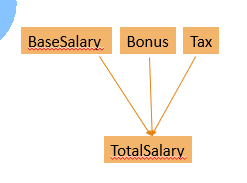

In [23]:
class BaseSalary:
    def __init__(self, salary: float):
        self.salary = salary

    def get_base_salary(self) -> float:
        return self.salary

In [24]:
class Bonus:
    def __init__(self, bonus_per: float):
        self.bonus_per = bonus_per

    def calculate_bonus(self, base_salary: float) -> float:
        return (self.bonus_per / 100) * base_salary

In [25]:
class Tax:
    def __init__(self, tax_per: float):
        self.tax_per = tax_per

    def calculate_tax(self, gross_salary: float) -> float:
        return (self.tax_per / 100) * gross_salary

In [26]:
class TotalSalary(BaseSalary, Bonus, Tax):
    def __init__(self, salary: float, bonus_per: float, tax_per: float):
        BaseSalary.__init__(self, salary)
        Bonus.__init__(self, bonus_per)
        Tax.__init__(self, tax_per)

    def calculate_total_salary(self) -> dict[str, float]:
        base_sal = self.get_base_salary()
        bonus = self.calculate_bonus(base_sal)
        gross_sal = base_sal + bonus
        tax = self.calculate_tax(gross_sal)
        net_sal = gross_sal - tax
        return {
            "base_salary": base_sal,
            "bonus": bonus,
            "gross_salary": gross_sal,
            "tax": tax,
            "net_salary": net_sal,
        }

In [28]:
s1 = TotalSalary(salary=50_000.0, bonus_per=12.0, tax_per=10.0)
print(type(s1))

<class '__main__.TotalSalary'>


In [29]:
s1.salary

50000.0

In [30]:
s1.bonus_per

12.0

In [31]:
s1.tax_per

10.0

In [32]:
salary_details = s1.calculate_total_salary()
print(salary_details)

{'base_salary': 50000.0, 'bonus': 6000.0, 'gross_salary': 56000.0, 'tax': 5600.0, 'net_salary': 50400.0}


In [33]:
s1.get_base_salary()

50000.0

In [34]:
s2 = TotalSalary(salary=1_00_000.0, bonus_per=25.0, tax_per=15.0)
print(type(s2))

<class '__main__.TotalSalary'>


In [35]:
sal_details2 = s2.calculate_total_salary()
print(sal_details2)

{'base_salary': 100000.0, 'bonus': 25000.0, 'gross_salary': 125000.0, 'tax': 18750.0, 'net_salary': 106250.0}


In [36]:
s2.get_base_salary()

100000.0

# 3. Multilevel Inheritance
Parent -> child -> grand child -> ...

In [37]:
class Employee2:
    def __init__(self, emp_id: int, name: str):
        self.emp_id = emp_id
        self.name = name

    def get_employee_info(self):
        print(f"Employee Id: {self.emp_id}, Name: {self.name}")

In [38]:
class Manager(Employee2):
    def __init__(self, emp_id: int, name: str, dept: str):
        super().__init__(emp_id, name)
        self.dept = dept

    def get_manager_department(self):
        print(f"Department of Manager : {self.dept}")

In [39]:
class ProjectManager(Manager):
    def __init__(self, emp_id: int, name: str, dept: str, project: str):
        super().__init__(emp_id, name, dept)
        self.project = project

    def get_project_name(self):
        print(f"Project Name: {self.project}")

In [40]:
e2 = Employee2(emp_id=108, name="Sai")
print(type(e2))

<class '__main__.Employee2'>


In [41]:
e2.emp_id

108

In [42]:
e2.name

'Sai'

In [44]:
e2.get_employee_info()

Employee Id: 108, Name: Sai


In [45]:
m2 = Manager(emp_id=103, name="Suresh", dept="Engineering")
print(type(m2))

<class '__main__.Manager'>


In [46]:
m2.dept

'Engineering'

In [47]:
m2.emp_id

103

In [48]:
m2.get_manager_department()

Department of Manager : Engineering


In [49]:
# Inherited from Employee2 class
m2.get_employee_info()

Employee Id: 103, Name: Suresh


In [50]:
m2.get_employee_info()
m2.get_manager_department()

Employee Id: 103, Name: Suresh
Department of Manager : Engineering


In [51]:
pm2 = ProjectManager(emp_id=102, name="Rahul", dept="Engineering", project="Tesla")
print(type(pm2))

<class '__main__.ProjectManager'>


In [52]:
pm2.emp_id

102

In [53]:
pm2.project

'Tesla'

In [54]:
pm2.get_project_name()

Project Name: Tesla


In [55]:
pm2.get_employee_info()
pm2.get_manager_department()
pm2.get_project_name()

Employee Id: 102, Name: Rahul
Department of Manager : Engineering
Project Name: Tesla


# 4. Hierarchical inheritance
Single Parent but multiple child class

In [56]:
class Shape:
    def perimeter(self):
        pass

    def area(self):
        pass

    def get_info(self):
        print(f"Perimeter : {self.perimeter():.2f}, Area: {self.area():.2f}")

In [58]:
class Rectangle(Shape):
    def __init__(self, width: float, height: float):
        self.width = width
        self.height = height

    def perimeter(self):
        return 2 * (self.width + self.height)

    def area(self):
        return self.width * self.height

In [59]:
import math


class Circle(Shape):
    def __init__(self, radius: float):
        self.radius = radius

    def perimeter(self):
        return 2 * math.pi * self.radius

    def area(self):
        return math.pi * (self.radius**2)

In [60]:
s1 = Rectangle(width=20, height=15)
print(type(s1))

<class '__main__.Rectangle'>


In [61]:
s1.width

20

In [62]:
s1.height

15

In [63]:
s1.perimeter()

70

In [64]:
s1.area()

300

In [65]:
s1.get_info()

Perimeter : 70.00, Area: 300.00


In [66]:
s2 = Circle(radius=45)
print(type(s2))

<class '__main__.Circle'>


In [70]:
s2.perimeter()

282.7433388230814

In [71]:
s2.area()

6361.725123519331

In [72]:
s2.get_info()

Perimeter : 282.74, Area: 6361.73


In [73]:
s = [
    Circle(radius=33),
    Rectangle(width=30, height=20),
    Circle(radius=20),
    Rectangle(width=33, height=45),
]

In [74]:
for i in s:
    print(type(i))
    i.get_info()

<class '__main__.Circle'>
Perimeter : 207.35, Area: 3421.19
<class '__main__.Rectangle'>
Perimeter : 100.00, Area: 600.00
<class '__main__.Circle'>
Perimeter : 125.66, Area: 1256.64
<class '__main__.Rectangle'>
Perimeter : 156.00, Area: 1485.00
